In [46]:
import numpy as np
import pandas as pd
import yfinance as yf
from pypfopt import black_litterman
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, EfficientFrontier, expected_returns
import pandas as pd
import joblib  # For saving and loading scalers
import matplotlib.pyplot as plt  # For plotting
from tensorflow.keras.models import Sequential, load_model
import warnings
warnings.filterwarnings("ignore")

In [18]:
risk_free_rate = 0.02  # Risk free rate

In [82]:
data = pd.read_csv("Top_4_stocks.csv")
data["Date"] = pd.to_datetime(data['Date'])
data.set_index("Date", inplace=True)
data.head(10)

,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,
2015-01-01,440.343475,386.326385,185.691818,1032.979614
2015-01-02,446.471832,393.918243,185.200363,1046.735840
2015-01-05,442.702271,390.533234,183.171738,1030.828857
2015-01-06,435.810760,382.373810,174.858582,992.825623
2015-01-07,437.082672,384.203430,178.664856,981.098083
2015-01-08,446.263672,386.140472,176.102951,991.689270
2015-01-09,451.258942,405.902893,179.919662,1019.487000
2015-01-12,447.281219,414.023071,177.828308,1018.431702
2015-01-13,445.569885,408.730286,176.332993,1013.643127


In [24]:
assets = data.columns
assets

Index(['HDFCBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS'], dtype='object')

In [108]:
import datetime
def get_market_cap_on_date(ticker_symbol, date_str):
    stock = yf.Ticker(ticker_symbol)
    # date = datetime.datetime.strptime(date_str, "%Y-%m-%d").date()
    hist = stock.history(start=date_str, end=(date + datetime.timedelta(days=1)).strftime("%Y-%m-%d"))
    if hist.empty:
        return f"No data available for {ticker_symbol} on {date_str}" 
    closing_price = hist["Close"].iloc[0]  # Get closing price on the given date
    shares_outstanding = stock.info.get("sharesOutstanding", None)
    if shares_outstanding is None:
        return None
    market_cap = closing_price * shares_outstanding
    return market_cap


def annualize_returns(returns, horizon=5):
    trading_days_per_year = 252
    annualized_returns = (1 + returns) ** (trading_days_per_year / horizon) - 1
    return annualized_returns

In [37]:
date = data.index[400]
for asset in assets:
    print(f"{asset}: {get_market_cap_on_date(asset, date)}")

HDFCBANK.NS: 4439509120492.531
INFY.NS: 1721673632919.9219
RELIANCE.NS: 2998598334521.3438
TCS.NS: 4043658985140.5


In [38]:
mcaps = {ticker: get_market_cap_on_date(ticker, date) for ticker in assets}
mcaps = pd.Series(mcaps)

In [39]:
initial_weights = mcaps / mcaps.sum()
initial_weights

HDFCBANK.NS    0.336239
INFY.NS        0.130396
RELIANCE.NS    0.227107
TCS.NS         0.306258
dtype: float64

In [52]:
training_dates = []
testing_dates = []

start_date = data.index[0 + 5]
end_date = data.index[-1]

# Generate training and testing date ranges
while start_date + pd.DateOffset(years=4) <= end_date:
    training_dates.append((start_date, start_date + pd.DateOffset(years=3)))
    testing_dates.append((start_date + pd.DateOffset(years=3), start_date + pd.DateOffset(years=4)))
    start_date += pd.DateOffset(years=1)

In [53]:
training_dates, testing_dates

([(Timestamp('2015-01-08 00:00:00'), Timestamp('2018-01-08 00:00:00')),
  (Timestamp('2016-01-08 00:00:00'), Timestamp('2019-01-08 00:00:00')),
  (Timestamp('2017-01-08 00:00:00'), Timestamp('2020-01-08 00:00:00')),
  (Timestamp('2018-01-08 00:00:00'), Timestamp('2021-01-08 00:00:00')),
  (Timestamp('2019-01-08 00:00:00'), Timestamp('2022-01-08 00:00:00')),
  (Timestamp('2020-01-08 00:00:00'), Timestamp('2023-01-08 00:00:00')),
  (Timestamp('2021-01-08 00:00:00'), Timestamp('2024-01-08 00:00:00'))],
 [(Timestamp('2018-01-08 00:00:00'), Timestamp('2019-01-08 00:00:00')),
  (Timestamp('2019-01-08 00:00:00'), Timestamp('2020-01-08 00:00:00')),
  (Timestamp('2020-01-08 00:00:00'), Timestamp('2021-01-08 00:00:00')),
  (Timestamp('2021-01-08 00:00:00'), Timestamp('2022-01-08 00:00:00')),
  (Timestamp('2022-01-08 00:00:00'), Timestamp('2023-01-08 00:00:00')),
  (Timestamp('2023-01-08 00:00:00'), Timestamp('2024-01-08 00:00:00')),
  (Timestamp('2024-01-08 00:00:00'), Timestamp('2025-01-08 00:0

In [55]:
t1 = pd.Timestamp("2024-03-11 10:30:00")
t2 = pd.Timestamp("2025-03-18 15:45:00")

def get_model_name(stock_name, idx):
    model_name = f"{stock_name}_{training_dates[idx][0].strftime('%Y%m%d')}_{training_dates[idx][1].strftime('%Y%m%d')}"
    print(model_name)
    return model_name

get_model_name(assets[1],0)

INFY.NS_20150108_20180108


'INFY.NS_20150108_20180108'

In [56]:
[d[1] for d in testing_dates]

[Timestamp('2019-01-08 00:00:00'),
 Timestamp('2020-01-08 00:00:00'),
 Timestamp('2021-01-08 00:00:00'),
 Timestamp('2022-01-08 00:00:00'),
 Timestamp('2023-01-08 00:00:00'),
 Timestamp('2024-01-08 00:00:00'),
 Timestamp('2025-01-08 00:00:00')]

In [120]:
# Backtest start and end dates
start_date = pd.to_datetime("2018-01-08")
end_date = pd.to_datetime("2025-01-08")

initial_weights = mcaps / mcaps.sum()  # Market-cap weights (Needs to be change based on the data)
initial_investment = 10000  # Initial portfolio value
portfolio_value = [initial_investment]
dates = [start_date]


model_change_dates = [d[1] for d in testing_dates] # all the dates when the model changes
model_number = 0

# Rebalancing frequency (e.g., every 30 days)
rebalance_frequency = 5

# initial model to use : assets : [model, scalar]
model_dict = {}
for asset in assets:
    model_name = get_model_name(asset, model_number)
    model = load_model(f"models/{model_name}.h5")
    scaler = joblib.load(f"models/{model_name}_scaler.pkl")
    model_dict[asset] = [model, scaler]

HDFCBANK.NS_20150108_20180108
INFY.NS_20150108_20180108
RELIANCE.NS_20150108_20180108
TCS.NS_20150108_20180108


In [122]:
# Backtest start and end dates
start_date = pd.to_datetime("2018-01-08")
end_date = pd.to_datetime("2025-01-08")

initial_weights = mcaps / mcaps.sum()  # Market-cap weights (Needs to be change based on the data)
initial_investment = 10000  # Initial portfolio value
portfolio_value = [initial_investment]
dates = [start_date]


model_change_dates = [d[1] for d in testing_dates] # all the dates when the model changes
model_number = 0

# Rebalancing frequency (e.g., every 30 days)
rebalance_frequency = 5

# initial model to use : assets : [model, scalar]
model_dict = {}
for asset in assets:
    model_name = get_model_name(asset, model_number)
    model = load_model(f"models/{model_name}.h5")
    scaler = joblib.load(f"models/{model_name}_scaler.pkl")
    model_dict[asset] = [model, scaler]
    
# List to store weights
W = []

# Backtest loop
current_date = start_date
while current_date < end_date:

    # Prepare the input data for prediction
    # Use the last 30 days of data as input to the LSTM model
    Q = {}

    for stock_name, [model, scaler] in model_dict.items():
        input_data = data.loc[:current_date][stock_name].tail(30).values.reshape(-1, 1)
        scaled_input_data = scaler.transform(input_data)

        # Predict 5-day returns using the LSTM model
        scaled_predicted_returns = model.predict(scaled_input_data.reshape(1, 30, 1),verbose=0)
        predicted_returns = scaler.inverse_transform(scaled_predicted_returns)[0]

        # annualize the predicted returns
        predicted_returns = annualize_returns(predicted_returns[0], horizon=5)

        Q[stock_name] = predicted_returns

    
    # View dictionary for Black-Litterman
    viewdict = Q

    # Covariance matrix (S)
    S = risk_models.sample_cov(data.loc[:current_date])  

    # Risk aversion parameter
    delta = 2.5

    # Market-implied prior returns
    prior = black_litterman.market_implied_prior_returns(mcaps, delta, S)

    # Black-Litterman model
    bl = BlackLittermanModel(S, pi=prior, absolute_views=viewdict)
    bl_returns = bl.bl_returns()

    # Efficient Frontier optimization
    ef = EfficientFrontier(bl_returns, S)
    ef.min_volatility()
    

    cleaned_weights = ef.clean_weights()
    
    # Store weights
    W.append(cleaned_weights)

    # Compute portfolio returns for the next rebalance period
    curr_date_index = data.index.get_loc(current_date)
    next_index = curr_date_index + 5
    if next_index >= len(data):
        next_index = len(data) - 1
    next_date = data.index[next_index]

    # Get actual returns for the rebalance period
    actual_returns = data.loc[current_date:next_date].pct_change().dropna()
    
    portfolio_return = (actual_returns * cleaned_weights).sum(axis=1)

    # Update portfolio value
    for j in range(len(portfolio_return)):
        portfolio_value.append(portfolio_value[-1] * (1 + portfolio_return[j]))

    print(f"Portfolio value at {next_date}: {portfolio_value[-1]}")
    dates.append(next_date)

    # Move to the next rebalance date
    current_date = next_date

    # changing model if the date is greater than the model change date
    if current_date >= model_change_dates[model_number]:
        model_number += 1

        try:
            for asset in assets:
                model_name = get_model_name(asset, model_number)
                model = load_model(f"models/{model_name}.h5")
                scaler = joblib.load(f"models/{model_name}_scaler.pkl")
                model_dict[asset] = [model, scaler]
        except:
            break
# Final portfolio value
print(f"Final portfolio value: {portfolio_value[-1]}")

Portfolio value at 2018-01-15 00:00:00: 10216.23851661064
Portfolio value at 2018-01-22 00:00:00: 10831.036445881346
Portfolio value at 2018-01-30 00:00:00: 10950.70635846069
Portfolio value at 2018-02-06 00:00:00: 10389.608973957056
Portfolio value at 2018-02-14 00:00:00: 10332.981966099158
Portfolio value at 2018-02-21 00:00:00: 10414.524927275663
Portfolio value at 2018-02-28 00:00:00: 10556.06391338439
Portfolio value at 2018-03-08 00:00:00: 10363.40334125005
Portfolio value at 2018-03-15 00:00:00: 10378.515169167727
Portfolio value at 2018-03-22 00:00:00: 10281.100386354223
Portfolio value at 2018-04-02 00:00:00: 10473.387596618122
Portfolio value at 2018-04-09 00:00:00: 10505.603053802484
Portfolio value at 2018-04-16 00:00:00: 10773.185068168743
Portfolio value at 2018-04-23 00:00:00: 10982.877988974578
Portfolio value at 2018-04-30 00:00:00: 11149.963337402669
Portfolio value at 2018-05-08 00:00:00: 11121.877559260807
Portfolio value at 2018-05-15 00:00:00: 11416.072820583413
P

In [90]:
# dates = data[pd.to_datetime("2018-01-01"):].index
# dates

In [123]:
len(portfolio_value)

1731

In [88]:
# historical_data = data.loc[:current_date].pct_change().dropna()
# S = risk_models.sample_cov(historical_data)  
# S.shape, Q

In [91]:
# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 6))
# plt.plot(dates,portfolio_value, label='Portfolio Value')

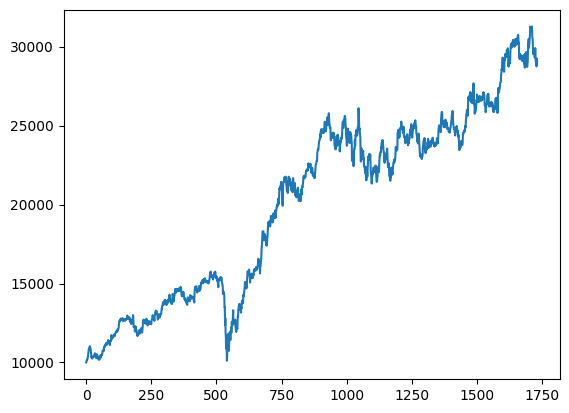

In [124]:
plt.plot(portfolio_value)

In [115]:
len(W), len(portfolio_value), len(dates)

(256, 1647, 257)

In [125]:
def get_sharpe_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    # print(annualized_return)
    annualized_volatility = portfolio_value.pct_change().std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / annualized_volatility

def get_sortino_ratio(portfolio_value):
    annualized_return = (portfolio_value.iloc[-1] / portfolio_value.iloc[0]) ** (252 / len(portfolio_value)) - 1
    downside_volatility = portfolio_value.pct_change()[portfolio_value.pct_change() < 0].std() * np.sqrt(252)
    return (annualized_return - risk_free_rate) / downside_volatility

def get_max_drawdown(portfolio_value):
    drawdown =  []
    peak = portfolio_value[0]

    for i in range(len(portfolio_value)):
        if portfolio_value[i] >= peak:
            peak = portfolio_value[i]
            drawdown.append(0)
        else:
            drawdown.append((portfolio_value[i] - peak) / peak)
    
    return drawdown

def get_volatility(portfolio_value):
    return portfolio_value.pct_change().std() * np.sqrt(252)

In [126]:
print(get_sharpe_ratio(pd.Series(portfolio_value)))
print(get_sortino_ratio(pd.Series(portfolio_value)))

0.7842466747628399
1.008811998976021


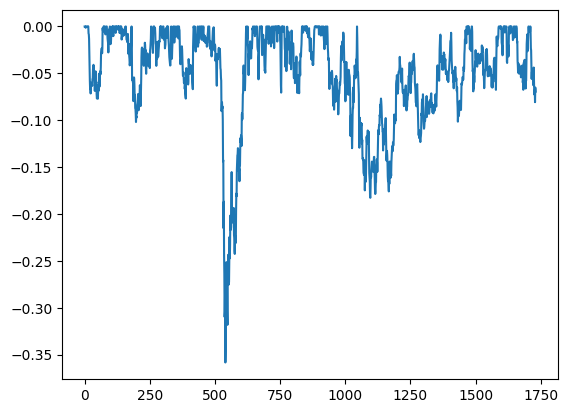

In [127]:
plt.plot(get_max_drawdown(portfolio_value), label="Equal Weights")

In [99]:
# plot weights
prior

HDFCBANK.NS    0.029070
INFY.NS        0.029809
RELIANCE.NS    0.033759
TCS.NS         0.030025
dtype: float64

In [100]:
# plot tsla
W

[OrderedDict([('HDFCBANK.NS', 0.52),
              ('INFY.NS', 0.13098),
              ('RELIANCE.NS', 0.12141),
              ('TCS.NS', 0.2276)]),
 OrderedDict([('HDFCBANK.NS', 0.5212),
              ('INFY.NS', 0.13072),
              ('RELIANCE.NS', 0.12213),
              ('TCS.NS', 0.22595)]),
 OrderedDict([('HDFCBANK.NS', 0.51828),
              ('INFY.NS', 0.13088),
              ('RELIANCE.NS', 0.12675),
              ('TCS.NS', 0.22409)]),
 OrderedDict([('HDFCBANK.NS', 0.52676),
              ('INFY.NS', 0.13581),
              ('RELIANCE.NS', 0.12423),
              ('TCS.NS', 0.21319)]),
 OrderedDict([('HDFCBANK.NS', 0.52508),
              ('INFY.NS', 0.13594),
              ('RELIANCE.NS', 0.12386),
              ('TCS.NS', 0.21513)]),
 OrderedDict([('HDFCBANK.NS', 0.52426),
              ('INFY.NS', 0.13664),
              ('RELIANCE.NS', 0.1234),
              ('TCS.NS', 0.2157)]),
 OrderedDict([('HDFCBANK.NS', 0.52376),
              ('INFY.NS', 0.13841),
             